In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from rouge_score import rouge_scorer

from src.data_utils import (
    read_dataset, clean_text, show_statistics, clean_short_tweet, save_dataset,
    split_data, tokenize_texts)
from src.next_token_dataset import AutocompleteDataset, collate_fn
from src.lstm_model import AutocompleteLSTM
from src.lstm_train import train_epoch
from src.eval_lstm import evaluate_token_accuracy, evaluate_rouge, show_autocomplete
from src.eval_transformer_pipeline import evaluate_rouge_transformer, show_autocomplete_transformer
from src.utils import get_config

/home/mle-user/dl_projects/text_autocomplete_project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = get_config("./configs/config.yaml")

Конфигурационные данные успешно загружены.


## Загрузка и подготовка данных

Загрузим исходный датасет твиттов:

In [3]:
df = read_dataset(config["raw_dataset_path"])

Количество записей в датасете: 1600498

Первая запись из датасета:
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

                                               tweet
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1  is upset that he can't update his Facebook by ...
2  @Kenichan I dived many times for the ball. Man...
3     my whole body feels itchy and like its on fire
4  @nationwideclass no, it's not behaving at all....


Записи содержат хештеги, адреса сайтов, обращения к пользователям (@user) и прочие лишние символы - проведем очистку датасета от этих данных.

In [4]:
texts = [clean_text(text) for text in df['tweet'].tolist()]
texts[:10]

['awww thats a bummer you shoulda got david carr of third day to do it d',
 'is upset that he cant update his facebook by texting it and might cry as a result school today also blah',
 'i dived many times for the ball managed to save 50 the rest go out of bounds',
 'my whole body feels itchy and like its on fire',
 'no its not behaving at all im mad why am i here because i cant see you all over there',
 'not the whole crew',
 'need a hug',
 'hey long time no see yes rains a bit only a bit lol im fine thanks hows you',
 'nope they didnt have it',
 'que me muera']

Записи содержат от 0 до 40 слов, причем существенное большинство из них приходятся на диапозон из 4 до 15 слов. Средняя длина записей - 12,5, медиана чуть ниже - 11.


Статистика по количеству слов в тексте:
Среднее: 12.47
Медиана: 11.00
Минимальное: 0.00
Максимальное: 40.00
5-й перцентиль: 3.00
95-й перцентиль: 25.00


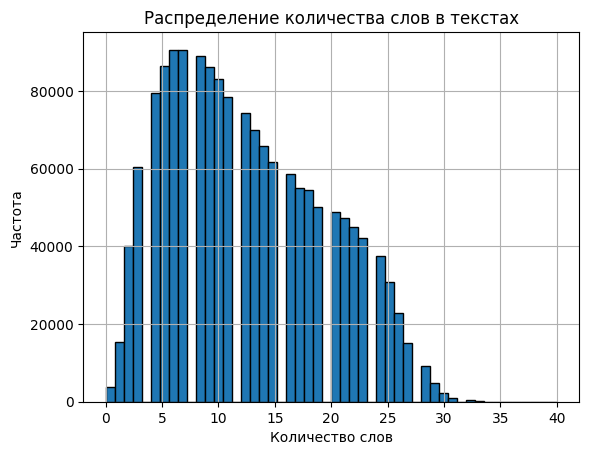

Топ-20 самых популярных слов в текстах:
[('i', 751135), ('to', 564692), ('the', 520264), ('a', 378269), ('my', 314141), ('and', 298493), ('you', 270168), ('is', 236130), ('it', 230937), ('for', 215775), ('in', 214280), ('of', 183492), ('im', 178382), ('on', 167129), ('me', 160120), ('so', 150817), ('have', 144550), ('that', 141372), ('but', 127501), ('just', 125100)]
Количество уникальных слов: 433354


In [5]:
show_statistics(texts)

Удалим самые короткие записи: от пустых (0 слов) до 5 перцентиля (3 слова):

In [6]:
texts = clean_short_tweet(texts, min_text_lenght=3)
print(f"Количество записей в датасете: {len(texts)}")
print(f"% от первоначального кол-ва записей: {round(len(texts) / df.shape[0] * 100, 2)}%")

Количество записей в датасете: 1541143
% от первоначального кол-ва записей: 96.29%


In [7]:
# сокращенная версия датасета для отладки кода проекта локально
debug = config["debug"]
if debug:
	debug_version_dataset_size = config["debug_version_dataset_size"]
	texts = texts[:debug_version_dataset_size]

Сохраним очищенный датасет:

In [8]:
save_dataset(texts, config["clean_dataset_path"])

Файл clean_dataset.csv успешно сохранен


Разделим датасет на 3 подвыборки:
- обучающую (80%)
- валидационнцю (10%)
- тестовую (10%)

In [9]:
train, val, test = split_data(
    texts,
    config["val_size"],
    config["test_size"],
    config["random_state"]
)

Обучающая выборка: 1232914 записей
Валидационная выборка: 154114 записей
Тестовая выборка: 154115 записей


In [10]:
save_dataset(train, config["train_dataset_path"])
save_dataset(val, config["val_dataset_path"])
save_dataset(test, config["test_dataset_path"])

Файл train_dataset.csv успешно сохранен
Файл val_dataset.csv успешно сохранен
Файл test_dataset.csv успешно сохранен


## Подготовка Dataloader'ов

Токенизируем тексты из всех выборок.\
В рамках проекта выбран токенизатор distilgpt2, поскольку задание предполагает использование во второй части трансформера distilgpt2,\
что делает логичным выбор токенизатора, который подойдет как для LSTM модели, так и для указанного трансформера.

In [11]:
tokenizer = AutoTokenizer.from_pretrained(config["tokenizer_model_name"])
if tokenizer.pad_token is None:
	tokenizer.pad_token = tokenizer.eos_token

tokenized_train = tokenize_texts(train, tokenizer)
tokenized_val = tokenize_texts(val, tokenizer)
tokenized_test = tokenize_texts(test, tokenizer)

Подготовим датасеты:

In [12]:
train_dataset = AutocompleteDataset(tokenized_train)
val_dataset = AutocompleteDataset(tokenized_val)
test_dataset = AutocompleteDataset(tokenized_test)

In [13]:
train_dataset[0]

{'text': tensor([37210,  2626,   981,   284, 14570,   318,  1682,  1107]),
 'answer': tensor([ 2626,   981,   284, 14570,   318,  1682,  1107,  3621])}

Создадим загрузчики данных (dataloaders), дополнив последовательности пэддингом и приведя их к единому размеру:

In [14]:
batch_size = config['batch_size']
padding = tokenizer.pad_token_id

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=lambda batch: collate_fn(batch, padding)
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=lambda batch: collate_fn(batch, padding)
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=lambda batch: collate_fn(batch, padding)
)

In [15]:
print(f'Количество батчей в train_dataloader: {len(train_dataloader)}')
print(f'Количество батчей в val_dataloader: {len(val_dataloader)}')
print(f'Количество батчей в test_dataloader: {len(test_dataloader)}')

Количество батчей в train_dataloader: 9633
Количество батчей в val_dataloader: 1205
Количество батчей в test_dataloader: 1205


In [16]:
print('Размерности батчей:')
for batch in train_dataloader:
    print('texts:', batch['texts'].shape)
    print('answers:', batch['answers'].shape)
    print('\nПример батча:')
    print(batch)
    break

Размерности батчей:
texts: torch.Size([128, 32])
answers: torch.Size([128, 32])

Пример батча:
{'texts': tensor([[ 5528,   275, 16261,  ..., 50256, 50256, 50256],
        [  258,   258,    71,  ..., 50256, 50256, 50256],
        [40716,   345,   290,  ..., 50256, 50256, 50256],
        ...,
        [37210,  3492,   329,  ..., 50256, 50256, 50256],
        [13929,   645,   475,  ..., 50256, 50256, 50256],
        [40909,  1312, 18548,  ..., 50256, 50256, 50256]]), 'answers': tensor([[  275, 16261,   310,  ..., 50256, 50256, 50256],
        [  258,    71,   345,  ..., 50256, 50256, 50256],
        [  345,   290,   976,  ..., 50256, 50256, 50256],
        ...,
        [ 3492,   329, 17150,  ..., 50256, 50256, 50256],
        [  645,   475,  1312,  ..., 50256, 50256, 50256],
        [ 1312, 18548,   787,  ..., 50256, 50256, 50256]]), 'lengths': tensor([ 6, 21, 24,  5, 16,  7,  8, 19, 11, 18, 15,  3, 12, 10, 32,  6, 19,  7,
        28, 12,  7,  5, 12, 21,  9, 13, 14,  3, 14, 14, 22, 16,  5,

## LSTM

Определим доступное устройство:

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Создадим LSTM модель, используя кастомный класс AutocompleteLSTM.\
Метод foreward модели предсказывает следующий токен, а метод generate - генерирует последовательность токенов.

In [18]:
# создание модели
model = AutocompleteLSTM(
    vocab_size=tokenizer.vocab_size,
    embed_dim=config["embed_dim"],
    hidden_dim=config["hidden_dim"],
    pad_idx=tokenizer.pad_token_id,
    dropout=config["dropout"]
).to(device)

Для удобства и лаконичности передачи данных в функции создадим словарь с ключевыми параметрами:
- устройство
- оптимизатор
- функция потерь
- клиппинг градиентов
- токенизатор

Они понадобится при обучении и оценке моделей.

In [19]:
params = {
    'device': device,
	'optimizer': torch.optim.Adam(model.parameters(), lr=float(config["lr"])),
	'criterion': nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id),
	'grad_clipping': config["grad_clipping"],
	'tokenizer': tokenizer,
	'split_ratio': config["rouge_split_ratio"],
    'max_new_tokens': config["max_new_tokens"]
}

Для оценки качества модели воспользуемся метрикой ROUGE и применим ее следующим образом:\
в качестве входа модель получает 3/4 исходного текста и старается дополнить оставшиеся 1/4.

In [20]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2'], use_stemmer=True)

Проведем обучение модели.\
В качестве метрик эпох обучения будем выводить Loss и token-level Accuracy (т.е. долю правильно предсказанных токенов).\
Для валидационной выборки также рассчитаем ROUGE.

!!! Удалить уменьшение кол-ва!!!!

In [ ]:
for epoch in range(config["n_epochs"]):
    train_loss, train_acc = train_epoch(model, train_dataloader, params)
    val_loss, val_acc = evaluate_token_accuracy(model, val_dataloader, params)
    rouge1, rouge2 = evaluate_rouge(model, tokenized_val[:1000], scorer, params)
    print(f"Epoch: {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"ROUGE-1: {rouge1:.4f} | ROUGE-2: {rouge2:.4f}")
    print("=" * 50)


  0%|                                                                                                | 5/9633 [00:12<7:40:05,  2.87s/it]

In [ ]:
show_autocomplete(model, tokenized_val, config['n_samples'], params)

Рассчитаем метрики ROUGE для LSTM на тестовых данных:

In [ ]:
rouge1, rouge2 = evaluate_rouge(model, tokenized_test, scorer, params)
print(f"ROUGE-1: {rouge1:.4f} | ROUGE-2: {rouge2:.4f}")


Также посмотрим на дополненные моделью тексты из тестовых данных:

In [ ]:
show_autocomplete(model, tokenized_test, config['n_samples'], params)

In [ ]:
save_path = congig["model_save_path"]
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(model.state_dict(), save_path)
print(f"Модель сохранена в {save_path}")

## Transformers

Загрузим предобученную модель трансформер distilgpt2 и оценим результаты работы данной модели на той же выборке


In [ ]:
model_transformer = AutoModelForCausalLM.from_pretrained(config["transformer_model_name"]).to(device)
model_transformer.eval()

In [ ]:
# tokenized_val = tokenized_val[:10]

Подготовим словарь параметров для дальнейшего удобства передачи в функции:

In [ ]:
transformer_params = {
    'device': device,
	'tokenizer': tokenizer,
	'split_ratio': config["rouge_split_ratio"],
    'max_new_tokens': config["max_new_tokens"],
    'temperature': config["temperature"],
    'top_k': config["top_k"]
}

Рассчитаем метрики ROUGE для Трансформера на валидационных данных:

In [ ]:
rouge1, rouge2 = evaluate_rouge_transformer(model_transformer, tokenized_val, scorer, transformer_params)
print(f"ROUGE-1: {rouge1:.4f} | ROUGE-2: {rouge2:.4f}")

А также посмотрим на примеры дополненных моделью фраз:

In [ ]:
n_samples = config['n_samples']

In [ ]:
show_autocomplete_transformer(
    model_transformer,
    tokenized_val,
    n_samples,
    transformer_params,
)

Посмотрим на эти же показатели, но на тестовых данных:

In [ ]:
rouge1, rouge2 = evaluate_rouge_transformer(model_transformer, tokenized_test, scorer, transformer_params)
print(f"ROUGE-1: {rouge1:.4f} | ROUGE-2: {rouge2:.4f}")

In [ ]:
show_autocomplete_transformer(
    model_transformer,
    tokenized_test,
    n_samples,
    transformer_params
)